# Extreme Value Analysis

Please refer to the following link for the theory on this topic.

https://tudelft-citg.github.io/HOS-prob-design/intro.html

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import plotly.graph_objects as go
import itertools
from scipy.signal import find_peaks
from matplotlib import pyplot as plt
from matplotlib.legend_handler import HandlerLine2D
import csv

%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6

from netCDF4 import Dataset

- Establish the Peak Over Threshold values.
- Starting point is Hs data in file hsarras=ys POT test.csv with 3 hour Hs data
- Here the Thershold (thresh) is chosen $H_s = 2.5 m$ and the time is 4 (j) * 3 hrs = 12 hrs
- Peaks delivers the POT values over which one should do the Weibull or Gumbel fit

## Extract data from dataset

In [2]:
data_csv_current = pd.read_csv('../../data/current_time_series.csv', parse_dates=True, date_format="ms") #Dataset('../../data/all_data.csv')
data_csv = pd.read_csv('../../data/all_data.csv', parse_dates=True, date_format="ms") #Dataset('../../data/all_data.csv')
pass

In [3]:
data_csv_current.head()

,Unnamed: 0,time,velocity,direction
0,0,2014-04-01 00:00:00+09:00,111.865,109.8
1,1,2014-04-01 01:00:00+09:00,110.168,112.3
2,2,2014-04-01 02:00:00+09:00,100.481,117.6
3,3,2014-04-01 03:00:00+09:00,83.176,131.0
4,4,2014-04-01 04:00:00+09:00,83.060,112.5


Extracting data from dataset

In [4]:
hs = data_csv["shww"]
tp = data_csv["pp1d"]
time = data_csv['valid_time']
parameter_interest = data_csv["mpts"]
#time = data_csv_current["time"]
#parameter_interest = data_csv_current["velocity"]




#time = data_csv["time"]

# hs_array = hs[:,1,1]
# period_array = tp[:,1,1]
# Time_array = time[:]

data = np.array([time, parameter_interest])
data = data.T

In [5]:
x = data_csv["mpww"] #mean period wind waves
y = data_csv["shww"] #significant height wind waves

plt.figure(figsize=(10,10))
plt.scatter(x, y, marker=".")
x_name, y_name = "mean wave period", "Wind wave height"
plt.title(f"Scatter plot of {x_name} vs {y_name}")
plt.ylabel(f"{y_name} [m]")
plt.xlabel(f"{x_name} [s]")
x_name, y_name = x_name.replace(" ", "_"), y_name.replace(" ", "_")
#plt.savefig(f"../Plots_svg/{x_name}{y_name}.png")
plt.close()

In [6]:
x = data_csv["mpts"] #mean period swell waves
y = data_csv["shts"] #significant height swell waves

plt.figure(figsize=(10,10))
plt.scatter(x, y, marker=".")
x_name, y_name = "Swell wave period", "Swell wave height"
plt.title(f"Scatter plot of {x_name} vs {y_name}")
plt.ylabel(f"{y_name} [m]")
plt.xlabel(f"{x_name} [s]")
x_name, y_name = x_name.replace(" ", "_"), y_name.replace(" ", "_")
#plt.savefig(f"../Plots_svg/{x_name}{y_name}.png")
plt.close()

In [7]:
x = data_csv["pp1d"] #peak period of wind and swell
y = data_csv["swh"] #significant height of wind and swell waves

plt.figure(figsize=(10,10))
plt.scatter(x, y, marker=".")
x_name, y_name = "Wind and swell wave period", "Wind and swell wave height"
plt.title(f"Scatter plot of {x_name} vs {y_name}")
plt.ylabel(f"{y_name} [m]")
plt.xlabel(f"{x_name} [s]")
x_name, y_name = x_name.replace(" ", "_"), y_name.replace(" ", "_")
#plt.savefig(f"../Plots_svg/{x_name}{y_name}.png")
plt.close()

In [8]:
x = data_csv["mpww"] #mean period wind waves
y = data_csv["mpts"] #mean period swell waves

plt.figure(figsize=(10,10))
plt.scatter(x, y, marker=".")
x_name, y_name = "Wind wave period", "Swell wave period"
plt.title(f"Scatter plot of {x_name} vs {y_name}")
plt.ylabel(f"{y_name} [s]")
plt.xlabel(f"{x_name} [s]")
x_name, y_name = x_name.replace(" ", "_"), y_name.replace(" ", "_")
#plt.savefig(f"../Plots_svg/{x_name}{y_name}.png")
plt.close()

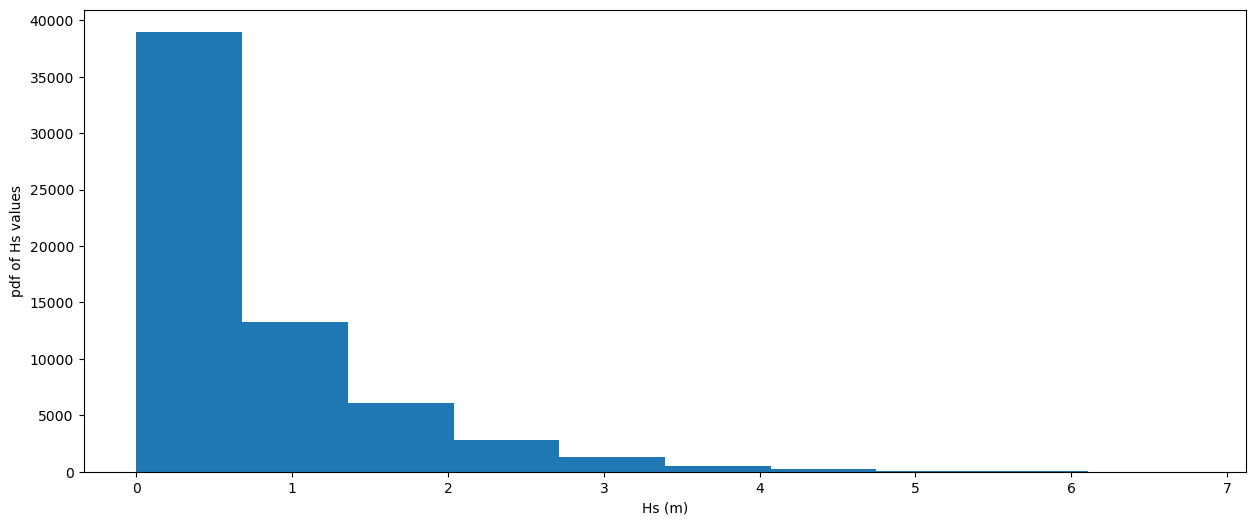

Number of Hs values:  64284



In [ ]:
#wave_data = pd.read_csv('data/hsarrays_POT_test.csv')
#time_series = wave_data['Hs']
# 
#  Extract Hs from database and plot histogram
#

fig, ax = plt.subplots(1, 1)
plt.xlabel('Parameter of interest')
plt.ylabel('pdf of Hs values')
ax.hist(hs, histtype='stepfilled')
plt.show()

#
imax = len(hs)
print('Number of Hs values: ',imax)
print()
#dft = wave_data.get("Extracted time")
pass

## Peak over threshold

In [10]:
#
# Peak Over Through code
def pot_method(data, threshold, dtime):
    idx_pot, _ = find_peaks(data, height = threshold, distance = dtime)
    pot_list = data[idx_pot]
    return idx_pot, pot_list
#

In [11]:
parameter_interest.mean()

np.float64(5.998105269656163)

In [12]:
fig = go.Figure(data=go.Scatter(
    y = parameter_interest,
    mode = 'lines'
))

fig.show()

In [13]:

#
# threshold is the Hs threshold value
# dtime is the number of values used in time (here 4 * 3 hour samples = 12 hrs)
#
threshold = 11
dtime = 10
tare = threshold

indices,pot_maxima = pot_method(parameter_interest, threshold, dtime)

kmax = len(pot_maxima)
print("Number of peaks based on Threshold: ",threshold," and time ",dtime," is: ",kmax)
print('Last part of the calculated Peaks over Threshold values: ')
print(pot_maxima[-5:])

Number of peaks based on Threshold:  11  and time  10  is:  109
Last part of the calculated Peaks over Threshold values: 
61674    11.852969
62232    11.292867
62344    12.230043
64204    11.289407
64262    11.244241
Name: mpts, dtype: float64


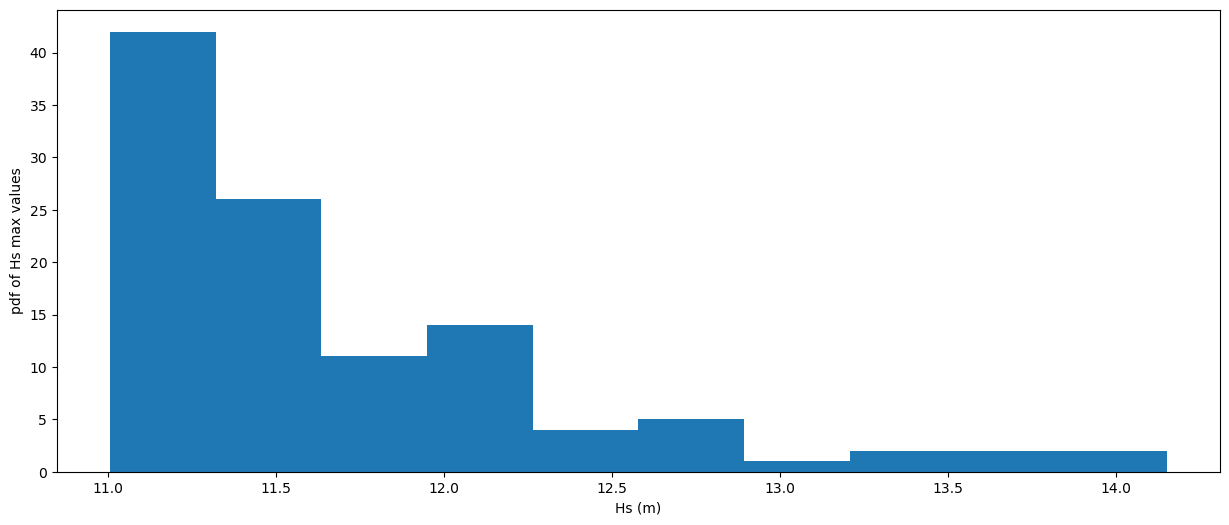

In [ ]:
#
#
# following is a subsegment to extract part of the data for visualization
# NB: j is starting value op peaks and range is number of points to be visualized
#
sub_ind = []
idx = []
j = 0
for i in range(0,24):
    k = j + i
    val = indices[k]
    idx.append(k)
    sub_ind.append(val)
#
sub_pot = pot_maxima.loc[sub_ind]

#
# Update numbers based on range!
#
inst = sub_ind[0]
inen = sub_ind[23]
sub_tim = parameter_interest[inst:inen]
sub_pos = list(itertools.chain(range(inst, inen)))
#
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=sub_pos,y=sub_tim,
    mode='lines',
    name='Original Plot'
))

#
#
fig.add_trace(go.Scatter(
    x=sub_ind,y=sub_pot,
    mode='markers',
    marker=dict(
        size=8,
        color='red',
        symbol='cross'
    ),
    name='Detected Peaks'
))

fig.show()

#
pot_time = []
for i in range(0,kmax):
    val = indices[i]
    pot_time.append(time[val])
#
fig, ax = plt.subplots(1, 1)
plt.xlabel('Parameter of interest')
plt.ylabel('pdf of Parameter of interest max values')
ax.hist(pot_maxima, histtype='stepfilled')
plt.show()
#
pass

In [15]:
array = np.array([indices, 
         pot_time,
         pot_maxima])

array = array.T

df = pd.DataFrame(array, columns=['index', 'pot_time', 'pot_maxima'])

df.to_csv('EVA result POT extremes.csv', index=False)


In [16]:
array[:, 2]

array([11.390342 , 11.21646  , 12.144008 , 11.156549 , 14.150982 ,
       11.471739 , 12.013848 , 12.03808  , 11.293492 , 11.828879 ,
       12.222765 , 11.335101 , 11.044978 , 11.317329 , 11.592493 ,
       11.999504 , 11.339011 , 11.874629 , 12.248335 , 11.598988 ,
       11.074235 , 11.321633 , 11.052184 , 11.283492 , 11.817295 ,
       11.981789 , 11.024295 , 11.629776 , 11.021972 , 11.587572 ,
       11.711971 , 12.517937 , 11.664453 , 13.555317 , 11.010143 ,
       11.221713 , 11.079304 , 11.0138445, 12.089981 , 11.338419 ,
       12.822505 , 11.294925 , 12.889879 , 11.196623 , 12.962577 ,
       11.078255 , 11.778171 , 12.1183   , 12.661358 , 12.624202 ,
       11.212231 , 12.59485  , 11.385087 , 11.3392105, 12.330507 ,
       11.207474 , 11.558829 , 11.610204 , 11.64806  , 11.292296 ,
       14.029738 , 11.528686 , 12.185475 , 11.459362 , 11.119258 ,
       12.2055025, 11.346595 , 11.268024 , 11.351657 , 12.575842 ,
       11.316271 , 12.321344 , 11.326814 , 11.059835 , 11.1573

## Extreme value distributions

In [17]:
import reliability.Fitters as rf

Tare the values of wave height against the threshold before fitting the distribution

In [18]:
dfmax = []
for it in pot_maxima:
    val = it - tare # pot_maxima[i]
    dfmax.append(val)    
dfmax.sort()

### Fit Weibull 2P

Results from Fit_Weibull_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 109/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
    Alpha         0.69203       0.0696951  0.568067  0.843044
     Beta         1.00168       0.0750384    0.8649    1.1601 

Goodness of fit    Value
 Log-likelihood -68.7966
           AICc  141.706
            BIC  146.976
             AD 0.625594 



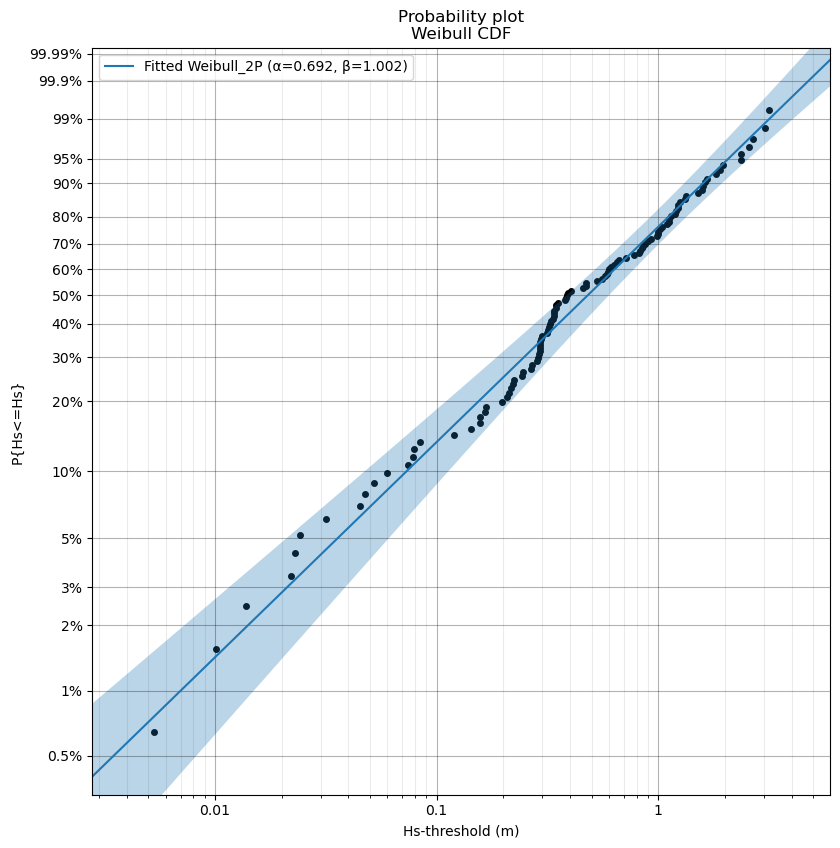

In [ ]:
waw2 = rf.Fit_Weibull_2P(failures=dfmax)
plt.ylabel('P{Parameter of interest<=Parameter of interest}')
plt.xlabel('Parameter of interest-threshold ')
plt.show()

### Fit Weibull 3P

Results from Fit_Weibull_3P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: L-BFGS-B
Failures / Right censored: 109/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
    Alpha         0.69203       0.0696951  0.568067  0.843044
     Beta         1.00168       0.0750384    0.8649    1.1601
    Gamma               0               0         0         0 

Goodness of fit    Value
 Log-likelihood -68.7966
           AICc  143.822
            BIC  151.667
             AD 0.625594 



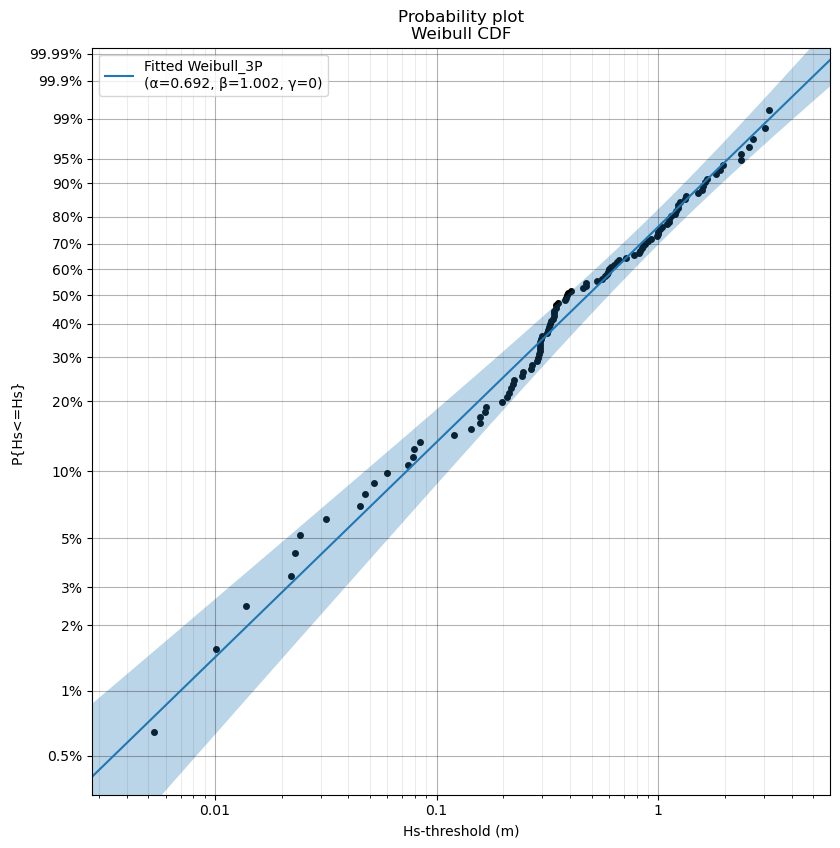

In [ ]:
#
#  Weibull 3P fit delivers alpha = scale factor, beta = shape factor & gamma = location factor

waw3 = rf.Fit_Weibull_3P(failures=dfmax)

plt.ylabel('P{Parameter of interest<=Parameter of interest}')
plt.xlabel('Parameter of interest-threshold')
plt.show()


### Fit Gumbel 2P

Results from Fit_Gumbel_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 109/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
       Mu         1.07541       0.0911183  0.896825     1.254
    Sigma        0.891756        0.055715  0.788978   1.00792 

Goodness of fit    Value
 Log-likelihood -143.434
           AICc  290.981
            BIC  296.251
             AD  9.99201 



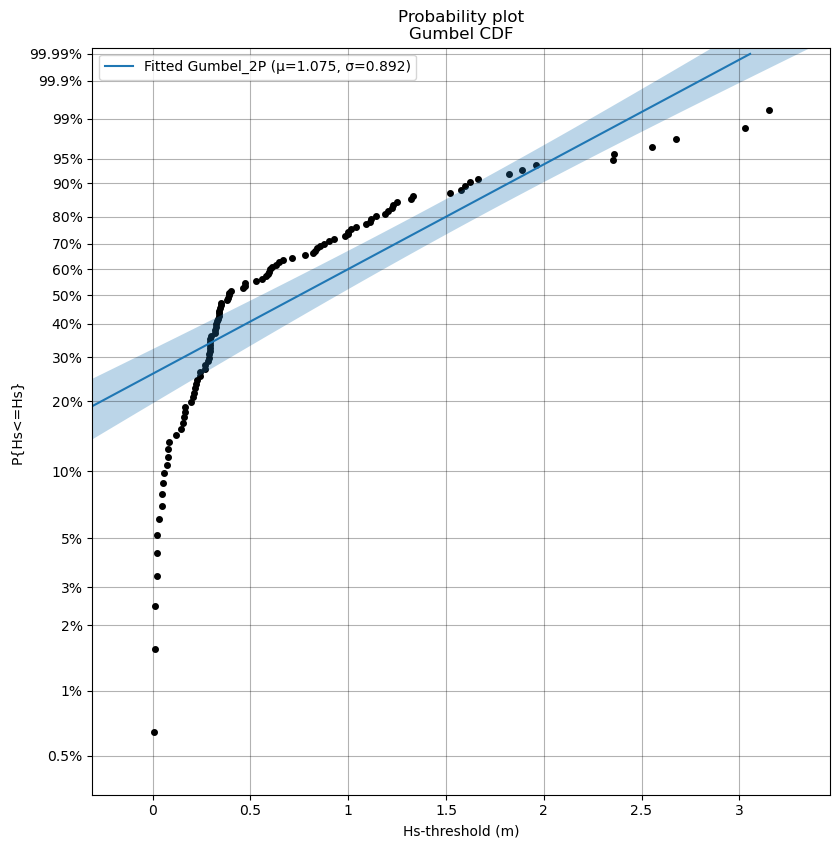

In [ ]:
wag = rf.Fit_Gumbel_2P(failures=dfmax)
plt.ylabel('P{Parameter of interest<=Parameter of interest}')
plt.xlabel('Parameter of interest-threshold ')
plt.show()

### Fit Exponential 2P

Results from Fit_Exponential_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 109/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
   Lambda           1.457        0.139556   1.20762   1.75789
 1/Lambda         0.68634       0.0657394  0.568864  0.828075
    Gamma        0.005199               0  0.005199  0.005199 

Goodness of fit    Value
 Log-likelihood -67.9743
           AICc  140.062
            BIC  145.331
             AD  0.66103 



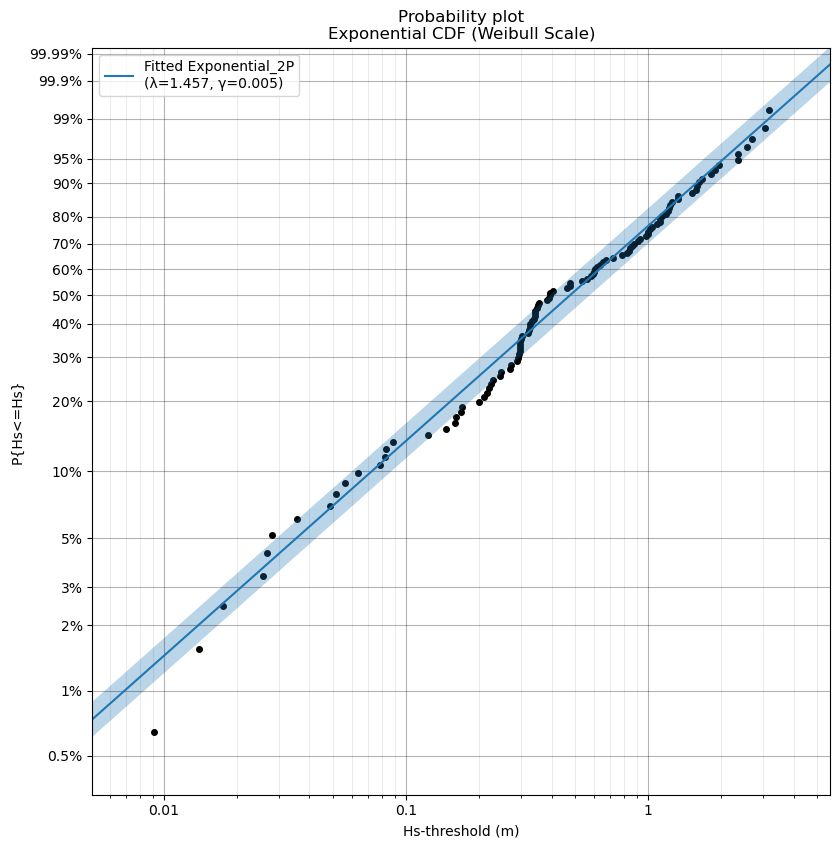

In [ ]:
wae = rf.Fit_Exponential_2P(failures=dfmax)
plt.ylabel('P{Parameter of interest<=Parameter of interest}')
plt.xlabel('Hs-threshold ')
plt.show()

## Gamma distribution

Results from Fit_Gamma_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 109/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
    Alpha        0.689842        0.105488  0.511196  0.930918
     Beta         1.00246        0.119589  0.793455   1.26652 

Goodness of fit    Value
 Log-likelihood -68.7967
           AICc  141.707
            BIC  146.976
             AD 0.625304 



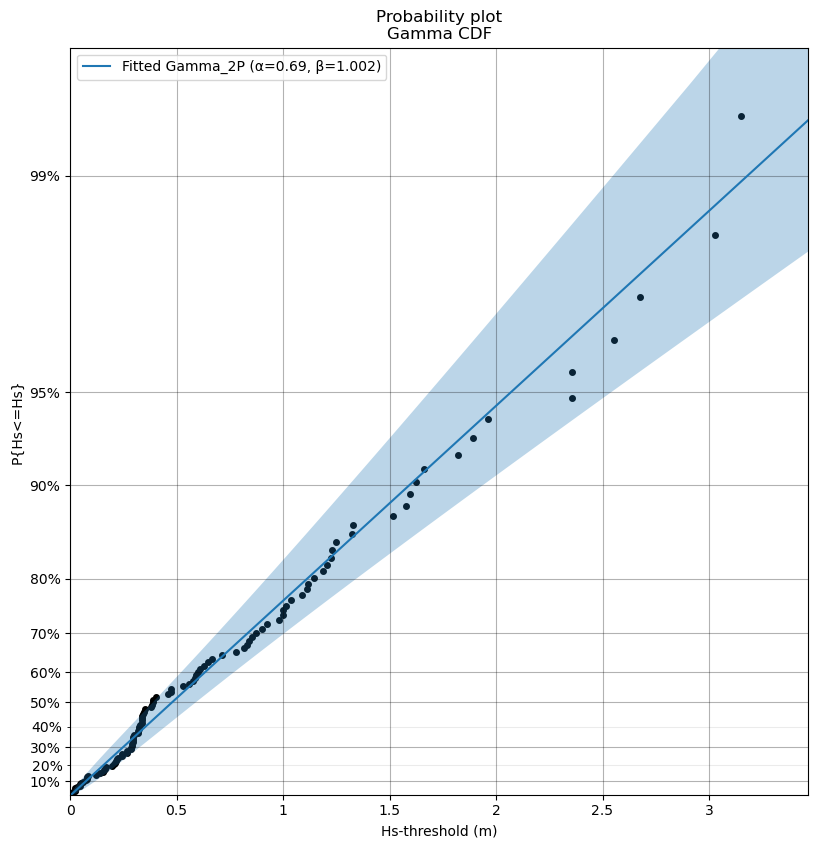

In [ ]:
gam = rf.Fit_Gamma_2P(failures=dfmax)
plt.ylabel('P{Parameter of interest<=Parameter of interest}')
plt.xlabel('Parameter of interest-threshold')
plt.show()

## Calculation of 100000 year return wave

In [30]:
#
#  Determine return period values
#
#
# define exceedance value for 100 yr return
# 
treturn = 100000
numberyears = 100
numb = len(pot_maxima) / numberyears
prob = 1 - 1/(numb * treturn)
print(prob)
1-1e-05

0.9999908256880734


0.99999

Ensure to add back the threshold tare in the estimated wave height value!

Weibull2P  100000 Year return value is  18.993902107830692  (m)
Weibull3P  100000 Year return value is  18.993902107830692  (m)
Gumbel  100000 Year return value is  14.261043170074618  (m)
Exponential  100000 Year return value is  18.966124430994526  (m)
Gamma2P  100000 Year return value is  19.006818569136342  (m)


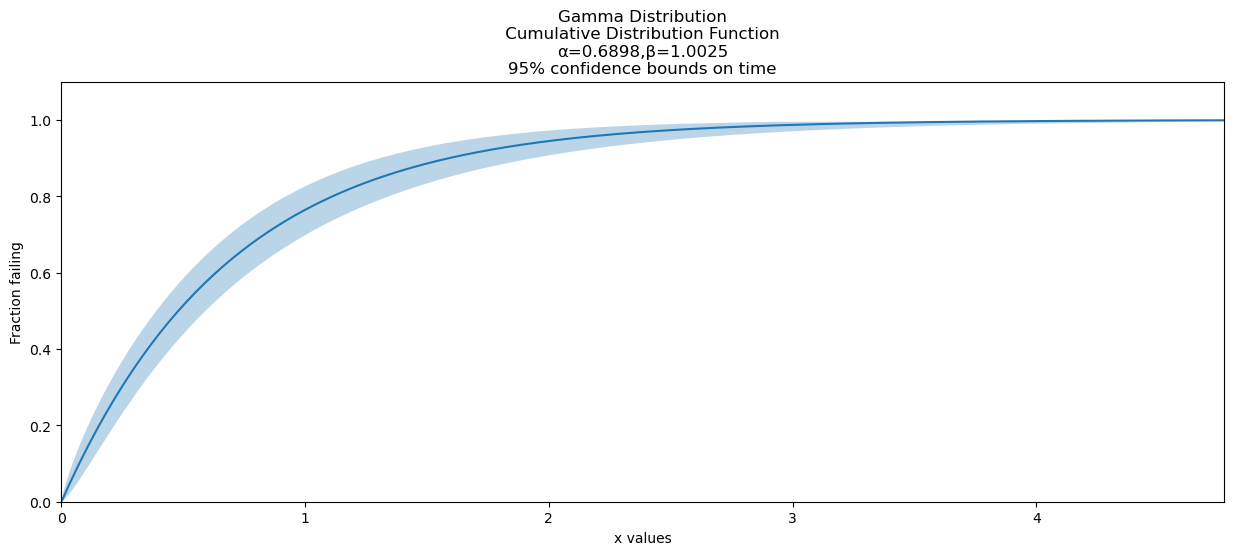

In [ ]:
# Weibull 2
X_lower,X_point,X_upper = waw2.distribution.CDF(CI_type='time',CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Weibull2P ',treturn,'Year return value is ',X_point)

# Weibull 3
X_lower,X_point,X_upper = waw3.distribution.CDF(CI_type='time',CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Weibull3P ',treturn,'Year return value is ',X_point)

# Gumbel
X_lower,X_point,X_upper = wag.distribution.CDF(CI_type='time',CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Gumbel ',treturn,'Year return value is ',X_point)

# Exponential
X_lower,X_point,X_upper = wae.distribution.CDF(CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Exponential ',treturn,'Year return value is ',X_point)

# gamma
X_lower,X_point,X_upper = gam.distribution.CDF(CI_y=prob,show_plot=True)
X_point = X_point + tare ## IMP
print('Gamma2P ',treturn,'Year return value is ',X_point)

## Compare all  distributions

Results from Fit_Everything:
Analysis method: MLE
Failures / Right censored: 109/0 (0% right censored) 

   Distribution    Alpha    Beta    Gamma  Alpha 1  Beta 1 Alpha 2  Beta 2 Proportion 1 DS       Mu    Sigma  Lambda Log-likelihood    AICc     BIC       AD optimizer
 Exponential_1P                                                                                              1.44605       -68.7969 139.631 142.285 0.624932       TNC
 Exponential_2P                  0.005199                                                                      1.457       -67.9743 140.062 145.331  0.66103       TNC
     Weibull_2P  0.69203 1.00168                                                                                           -68.7966 141.706 146.976 0.625594       TNC
       Gamma_2P 0.689842 1.00246                                                                                           -68.7967 141.707 146.976 0.625304       TNC
     Weibull_CR                            0.69669 0.98396 3

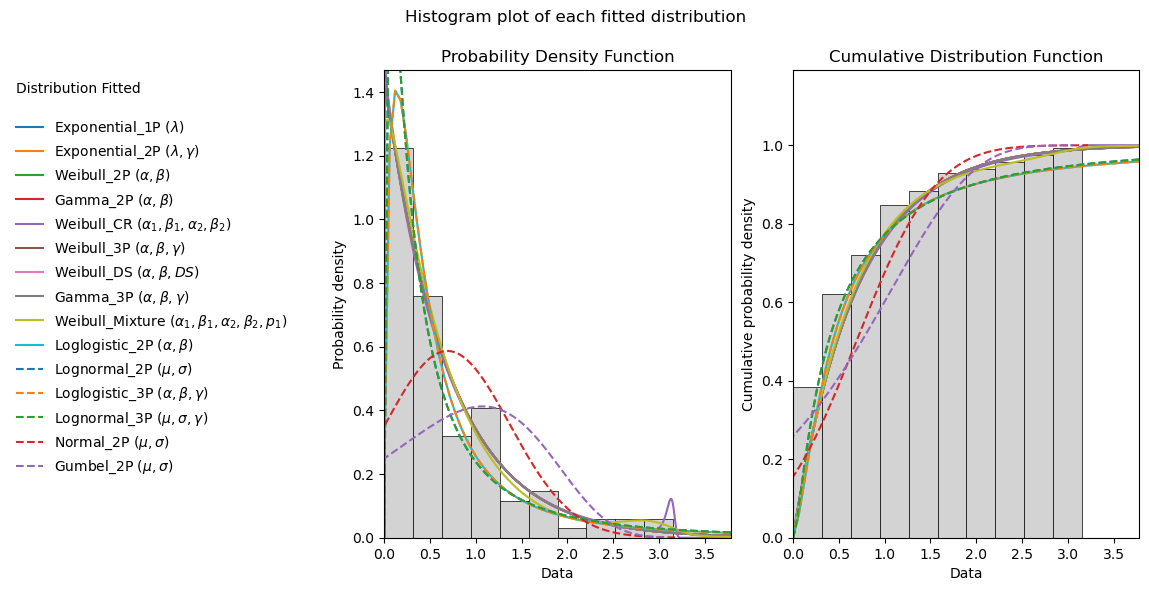

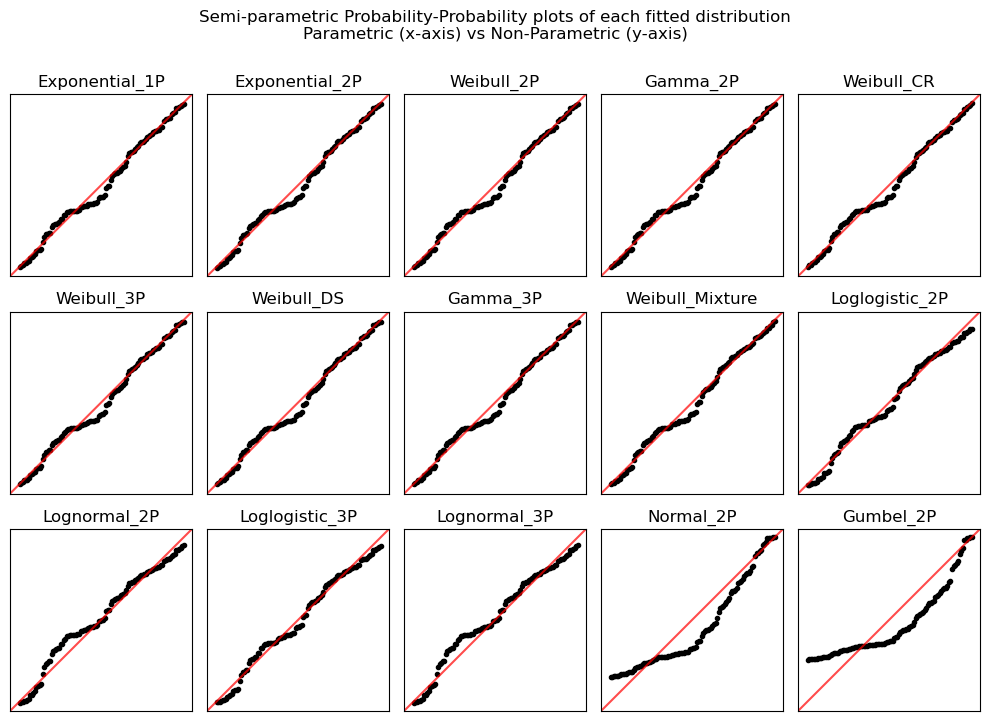

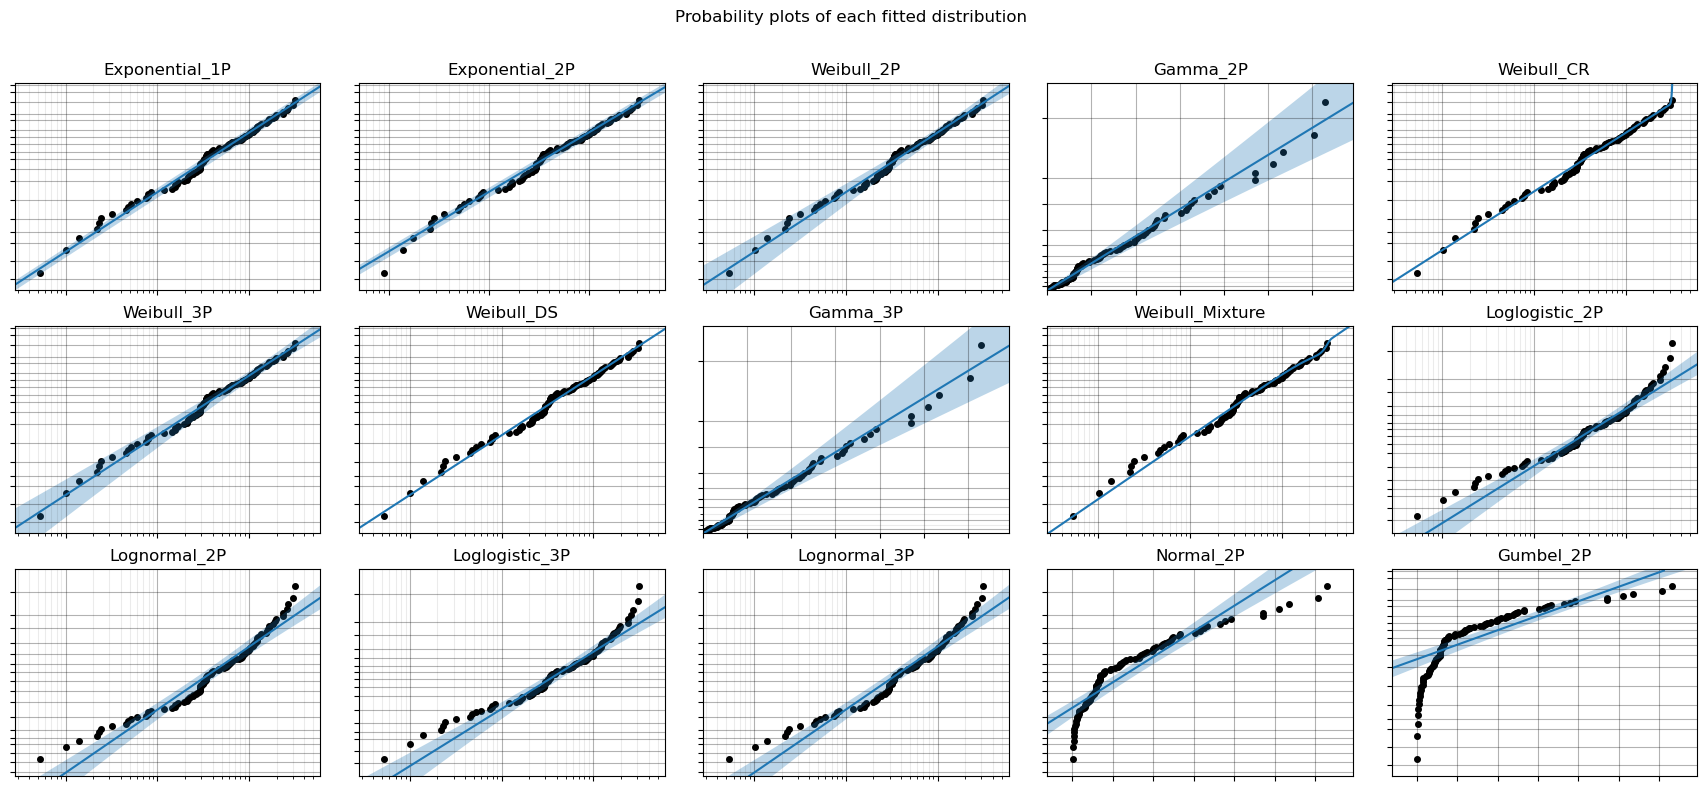

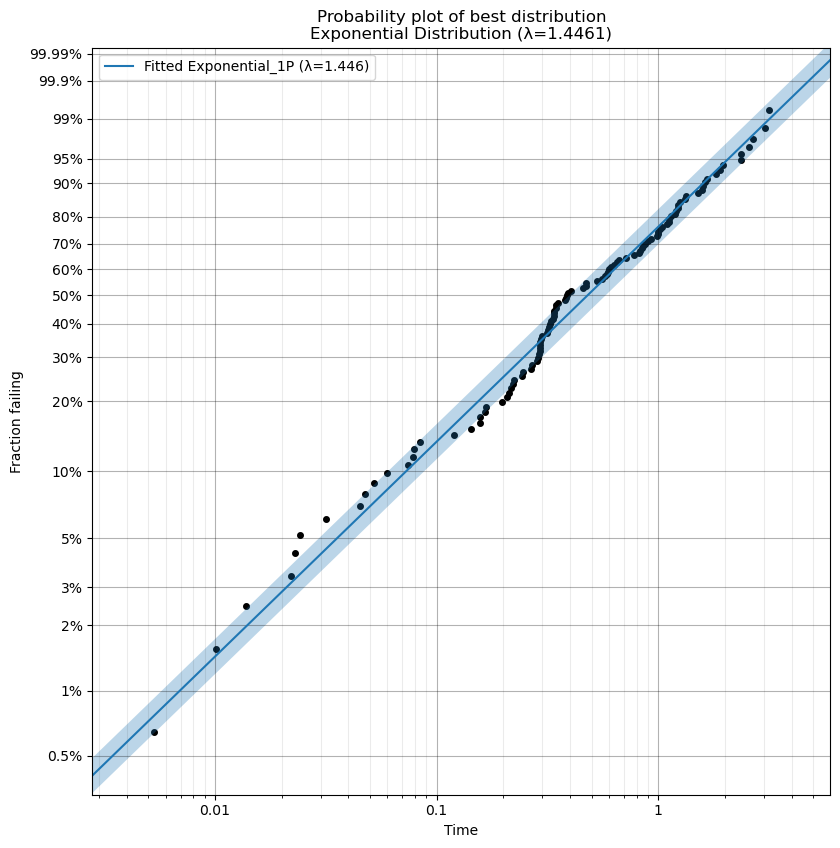

The best fitting distribution was Exponential_1P which had parameters [1.44605059 0.        ]


In [26]:
results = rf.Fit_Everything(failures=dfmax)  # fit all the models
best_fit_name, best_fit_params = results.best_distribution_name, results.best_distribution
print('The best fitting distribution was', results.best_distribution_name, 'which had parameters', results.best_distribution.parameters)
testres = results.best_distribution.CDF(CI=prob, show_plot=False)